# Lab 1: Exploratory Data Analysis on a Premier League Injury Dataset

**ADSA 8035, Week 1**  |  Estimated time: about 3 hours

Welcome to your first lab. You will explore a real dataset of Premier League injuries from 2019 to 2023: who got hurt, how long they were out, and how their clubs fared without them.

**Before you start:**
1. No data setup needed: the dataset loads automatically from the course Google Drive when you run the loading cell below. (It is the Kaggle Premier League injury dataset; the course page links the original source.)
2. Run cells top to bottom as you go. Your submitted notebook must run cleanly from top to bottom.
3. Complete every task marked **TODO**. Markdown prompts marked **YOUR INTERPRETATION** are where you write, and they matter as much as the code.

**AI policy reminder:** AI coding assistants are allowed and encouraged as co-pilots. At the end of the notebook you will disclose how you used them. You must be able to explain every line you submit.

## Task 1: Load Modules and Dataset

We split into train and test **before** exploring. We will model these data in Week 3, and the test set needs to stay out-of-sample, which means our eyes stay off it too. Note the `na_values` argument: this dataset records some missing results as the text "N.A.", and we want pandas to treat those as proper missing values.

*Companion: `notebooks/deep_dives/Week01_DeepDive.ipynb` derives this week's ideas in full; work it before this lab.*

*Data note: this notebook loads its dataset automatically from the course Google Drive when you run the loading cell. No download or upload needed.*

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set global font size for figures
plt.rcParams.update({'font.size': 12})

### The date columns need a real parser, not a one-liner

This file records dates three different ways, and one of those ways silently parses to the year 1 if you let pandas guess. That single quiet failure turns a median absence of 25 days into a mean of minus sixteen thousand. We write the parser once, name every quirk it handles, and flag the rows that are genuinely wrong in the source rather than absorbing them into an average.

In [ ]:
def parse_injury_dates(s):
    """Parse this file's date columns. The source is not uniform, so this is
    not a one-liner and pretending otherwise silently corrupts days_out.

    Three real quirks in the raw column:
      1. Most rows read "Nov 9, 2019" but 48 read "Jan 6,2024" with no space.
      2. Three rows spell the month out: "January 4, 2023".
      3. Three rows say "Present", meaning the player had not returned when
         these data were collected. That is not a bad date, it is information.
    """
    txt = s.astype("string").str.strip()
    txt = txt.replace({"Present": pd.NA, "present": pd.NA})
    txt = txt.str.replace(r",(?=\S)", ", ", regex=True)
    parsed = pd.to_datetime(txt, format="%b %d, %Y", errors="coerce")
    spelled = pd.to_datetime(txt, format="%B %d, %Y", errors="coerce")
    return parsed.fillna(spelled)


def add_days_out(df, injury_col="Date of Injury", return_col="Date of return"):
    """Build injury_date, return_date and days_out, and flag impossible rows.

    A handful of rows survive parsing and are still wrong: a return date before
    the injury date, and one source typo giving the year 0202. We do not
    silently absorb those. We mark them, print the count, and leave days_out
    missing so nothing downstream averages a number we know is false.
    """
    df = df.copy()
    df["injury_date"] = parse_injury_dates(df[injury_col])
    df["return_date"] = parse_injury_dates(df[return_col])
    raw_days = (df["return_date"] - df["injury_date"]).dt.days
    df["still_injured"] = df[return_col].astype("string").str.strip().eq("Present")
    df["date_error"] = (raw_days < 0) | (raw_days > 1200)
    df["days_out"] = raw_days.mask(df["date_error"])
    return df

In [ ]:
injury_url = "https://drive.google.com/uc?export=download&id=1Uaftofu7Ygip2-LOmdyGqQGjK_Ci6QWh"

injury_df = pd.read_csv(injury_url, na_values=["N.A."])

# Train/test split
x_train, x_test = train_test_split(injury_df, test_size=0.25, random_state=42)
x_train.head()

,Name,Team Name,Position,Age,Season,FIFA rating,Injury,Date of Injury,Date of return,Match1_before_injury_Result,...,Match1_after_injury_GD,Match1_after_injury_Player_rating,Match2_after_injury_Result,Match2_after_injury_Opposition,Match2_after_injury_GD,Match2_after_injury_Player_rating,Match3_after_injury_Result,Match3_after_injury_Opposition,Match3_after_injury_GD,Match3_after_injury_Player_rating
338,Anthony Martial,Man United,Center Forward,26,2021/22,79,Fitness,"Oct 15, 2021","Oct 29, 2021",win,...,-3.0,7,win,Arsenal,1.0,7,NaN,NaN,NaN,NaN
530,Jay Rodríguez,Burnley,Center Forward,30,2019/20,76,ill,"Jan 5, 2020","Jan 18, 2020",lose,...,1.0,6.4,win,Man United,2.0,6.8,draw,Arsenal,0.0,6.5
176,Thomas Partey,Arsenal,Defensive Midfielder,29,2021/22,84,Ankle injury,"Jul 29, 2021","Aug 30, 2021",NaN,...,1.0,7,win,Burnley,1.0,6.5,win,Tottenham,2.0,6.8
140,Mesut Özil,Arsenal,Attacking Midfielder,31,2019/20,85,Ankle injury,"Dec 16, 2019","Dec 26, 2019",lose,...,0.0,6.3,lose,Chelsea,-1.0,5.9,win,Man United,2.0,6
318,Fred,Man United,Central Midfielder,27,2021/22,79,Coronavirus,"Feb 7, 2022","Feb 14, 2022",draw,...,2.0,6,win,Leeds,2.0,6,draw,Watford,0.0,6


In [ ]:
x_train["Name"].value_counts()


,count
Name,
Giovani Lo Celso,9
Jóhann Berg Gudmundsson,8
Callum Wilson,8
Jonjo Shelvey,7
Scott McToMinay,7
...,...
Dwight McNeil,1
Sergi Canos,1
Tom Heaton,1


**YOUR INTERPRETATION:** In one or two sentences, what does one row in this dataset represent? (Hint: is it a player, a match, or something else?)

**My Interpretation:** One row represents a single injury epeisode per player, not the player overall. As we can see from the list above, the same player name appears multiple times. This occurs if the player was injured more than once.

## Task 2: Build a Data Dictionary

Run the cell below to list the columns, then complete the markdown table for at least ten columns you expect to use. One plain-language line per column.

In [ ]:
print("Number of rows: " + str(len(x_train)))
print("****************")
print("Number of columns: " + str(len(x_train.columns)))
print("****************")
print(list(x_train.columns))

Number of rows: 492
****************
Number of columns: 42
****************
['Name', 'Team Name', 'Position', 'Age', 'Season', 'FIFA rating', 'Injury', 'Date of Injury', 'Date of return', 'Match1_before_injury_Result', 'Match1_before_injury_Opposition', 'Match1_before_injury_GD', 'Match1_before_injury_Player_rating', 'Match2_before_injury_Result', 'Match2_before_injury_Opposition', 'Match2_before_injury_GD', 'Match2_before_injury_Player_rating', 'Match3_before_injury_Result', 'Match3_before_injury_Opposition', 'Match3_before_injury_GD', 'Match3_before_injury_Player_rating', 'Match1_missed_match_Result', 'Match1_missed_match_Opposition', 'Match1_missed_match_GD', 'Match2_missed_match_Result', 'Match2_missed_match_Opposition', 'Match2_missed_match_GD', 'Match3_missed_match_Result', 'Match3_missed_match_Opposition', 'Match3_missed_match_GD', 'Match1_after_injury_Result', 'Match1_after_injury_Opposition', 'Match1_after_injury_GD', 'Match1_after_injury_Player_rating', 'Match2_after_injury_R

In [ ]:
x_train["FIFA rating"].describe()


,FIFA rating
count,492.000000
mean,78.504065
std,4.083395
min,66.000000
25%,76.000000
50%,78.000000
75%,81.000000
max,90.000000


In [ ]:
x_train["Match1_before_injury_Result"].value_counts()

,count
Match1_before_injury_Result,
win,191
lose,163
draw,90


**TODO: your data dictionary** (edit this table, add rows as needed)

| Column | What it means (plain language) |
|---|---|
| Name |Full name of player  |
| Team Name |Name of PL team the player represents  |
| Position | Position on the field |
| Age |Age during that season |
| Season |Football season (e.g 2021/22) |
| FIFA rating | Rating of the player during that season on FIFA |
| Injury | Type of injury sustained by the player |
| Date of Injury | Date when the player sustained the injury |
| Date of return |Date when the player returned to play |
| Match1_before_injury_Result |The outcome of the previous match ( Win, Loss, Draw) |

## Task 3: Univariate Distributions

Use `describe()` and at least **two histograms** to explore how key variables are distributed. `Age` and `FIFA rating` are natural starts. Then create the `days_out` variable using the date-parsing pattern below and plot its distribution too; it is the most important number in this dataset and it does not exist until you build it.

In [ ]:
x_train.describe()

,Age,FIFA rating,Match1_before_injury_GD,Match2_before_injury_GD,Match3_before_injury_GD,Match1_missed_match_GD,Match2_missed_match_GD,Match3_missed_match_GD,Match1_after_injury_GD,Match2_after_injury_GD,Match3_after_injury_GD
count,492.000000,492.000000,444.000000,423.000000,384.000000,490.000000,368.000000,279.000000,388.000000,366.000000,329.000000
mean,26.678862,78.504065,0.225225,0.208038,0.015625,-0.083673,0.019022,0.139785,0.105670,0.188525,0.212766
std,3.661675,4.083395,2.041045,1.917550,1.960382,1.882852,1.835813,1.911296,1.936103,1.923176,1.823882
min,18.000000,66.000000,-6.000000,-5.000000,-7.000000,-5.000000,-5.000000,-5.000000,-5.000000,-7.000000,-5.000000
25%,24.000000,76.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,27.000000,78.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,29.000000,81.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,39.000000,90.000000,9.000000,9.000000,8.000000,5.000000,8.000000,5.000000,6.000000,8.000000,9.000000


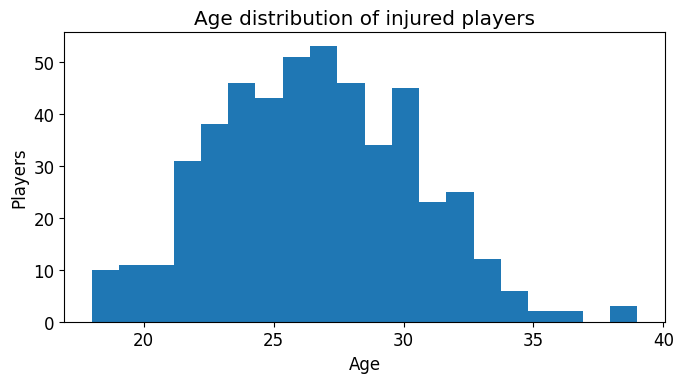

In [ ]:
# Parse dates and create days_out
x_train = add_days_out(x_train)

# histogram of Age
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x_train["Age"].dropna(), bins=20)
ax.set_xlabel("Age")
ax.set_ylabel("Players")
ax.set_title("Age distribution of injured players")
plt.tight_layout()
plt.show()

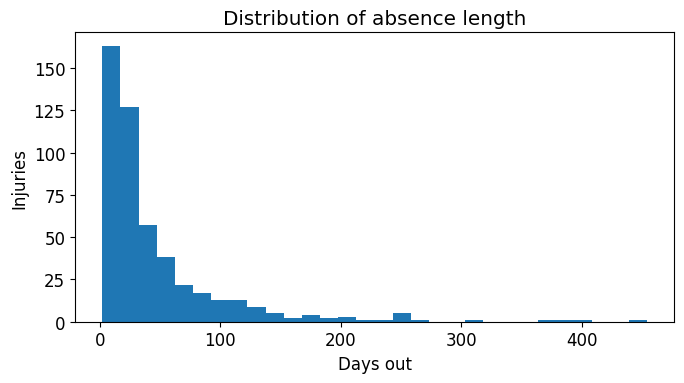

In [ ]:

# TODO: histogram of days_out (try bins=30)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(x_train["days_out"].dropna(), bins=30)
ax.set_xlabel("Days out")
ax.set_ylabel("Injuries")
ax.set_title("Distribution of absence length")
plt.tight_layout()
plt.show()

In [ ]:
print(x_train["days_out"].median())
print(x_train["days_out"].mean())

26.0
46.37909836065574


**YOUR INTERPRETATION:** Describe the shape of the `days_out` distribution. Why do the mean and median tell different stories here, and which would you report to a medical staff?

**My Interpretation:** We can see tha the days_out distribution is heavily right skewed. most injuries resolve in under 50 days but a small number of severe cases stretch past 300-400 days, pulling the mean (46.3) well above the median (26). The median is the more honest asnwer to the medical staff, it reflects what a typical injury actually looks like, while the mean is distorted by a handful of extreme cases.

## Task 4: Missingness Audit

Count missing values per column. Then, and this is the important part, pick **two** columns with meaningful missingness and write a hypothesis for **why** those values are missing. Do not impute anything. Investigate first.

In [ ]:
# TODO: count missing values per column

x_train.isnull().sum().sort_values(ascending=False)

,0
Match3_missed_match_Opposition,213
Match3_missed_match_Result,213
Match3_missed_match_GD,213
Match3_after_injury_Player_rating,164
Match3_after_injury_Result,163
Match3_after_injury_Opposition,163
Match3_after_injury_GD,163
Match2_after_injury_Player_rating,127
Match2_after_injury_Opposition,126
Match2_after_injury_Result,126


**YOUR INTERPRETATION:** For two columns with missing values, what is your best hypothesis for the mechanism behind the missingness? Is the blank itself informative? (Think about the football calendar, 2020, and what a missing return date might mean.)

**My Interpretation**: Match3_missed_match_ is missing for 213 of 492 rows (43%) and missingness increases steadily from Match1 to Match3, this is because this requires the player to have missed at least three matches, so short injuries wont appear. Its not random, its a direct function of injury severity.

On the other hand one variable that only has 4 rows of missing data is days_out. I would assume that this refers to the players who were still injured during the momment the data was collected.


## Task 5: Bivariate Relationships

Explore at least **two** relationships. Required: something involving `days_out`. Ideas: age vs. days out, average days out by injury type or by position, FIFA rating of injured players by club. Use `corr()`, `groupby()`, or a scatter plot, whichever fits.

In [ ]:
# TODO: relationship 1

age_bins = pd.cut(x_train["Age"], bins=[16, 23, 27, 31, 40],
                   labels=["Under 23", "23-27", "28-31", "32+"])
print(x_train.groupby(age_bins)["days_out"].agg(["median", "mean", "count"]).round(1))

          median  mean  count
Age                          
Under 23    25.0  44.5     99
23-27       26.0  47.4    192
28-31       28.0  47.1    147
32+         21.5  44.1     50


In [ ]:
injury_counts = x_train["Injury"].value_counts()
print(injury_counts.head(20))

Injury
Hamstring injury    54
Ankle injury        33
Knee injury         29
Calf injury         21
hamstring injury    17
knee injury         16
Coronavirus         15
Groin injury        14
Knock               13
hamstring strain    13
unknown injury      12
calf injury         10
Hamstring strain     9
Foot injury          8
Ill                  8
Hip injury           7
Muscle injury        7
muscle injury        7
Shoulder injury      7
ankle injury         7
Name: count, dtype: int64


In [ ]:
x_train["Injury_clean"] = x_train["Injury"].str.lower().str.strip()

injury_stats = x_train.groupby("Injury_clean")["days_out"].agg(["median", "count"])
print(injury_stats[injury_stats["count"] >= 5].sort_values("median", ascending=False))

                  median  count
Injury_clean                   
knee surgery       102.5      6
shoulder injury     66.5     10
knee injury         39.0     43
back injury         37.5      6
ankle injury        35.0     40
foot injury         33.5     10
calf injury         33.0     31
hip injury          32.0      8
hamstring strain    30.5     22
hamstring injury    30.0     71
muscle injury       26.5     14
fitness             25.0      5
bruise              25.0      7
thigh problems      23.5     10
muscle strain       20.5      6
groin injury        20.0     19
unknown injury      16.0     15
knock               14.0     14
coronavirus         13.0     15
head injury         12.0      6
ill                  7.0     12


**YOUR INTERPRETATION:** State each relationship you found in one sentence a coach would understand. Then add one sentence of caution: what could be confounding it?

**My Interpretation**
Player age does not seem to meaninfully change how long an injury keep someone out, the median days out is close across all age bands (25 to 28 days) with no clear age pattern.

Recovery time tracks injury severity in an intuitive way. Players out for knee surgery miss a median of over 100 days, while players with illneses like coronavirus or general sickness are back in under two weeks.

## Task 6: Two to Three Captioned Visualizations

Produce your two or three best figures (they may be polished versions of plots from Tasks 3 and 5). Every figure needs axis labels and a one-sentence caption in markdown underneath stating what the reader should take away.

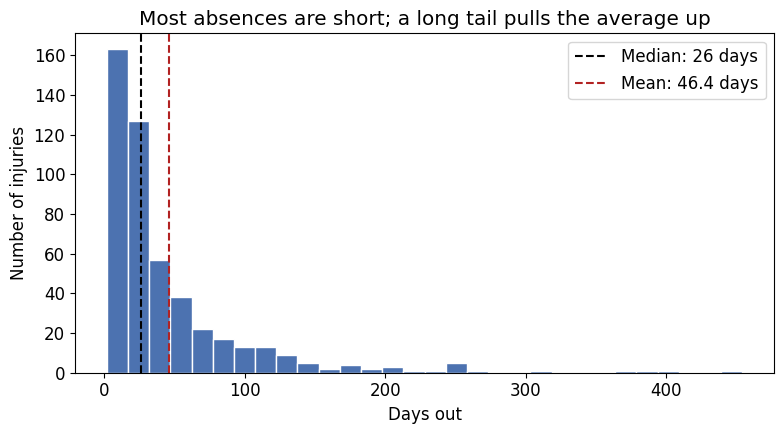

In [ ]:
# TODO: polished visualization 1

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(x_train["days_out"].dropna(), bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(x_train["days_out"].median(), color="black", linestyle="--", linewidth=1.5, label=f"Median: {x_train['days_out'].median():.0f} days")
ax.axvline(x_train["days_out"].mean(), color="firebrick", linestyle="--", linewidth=1.5, label=f"Mean: {x_train['days_out'].mean():.1f} days")
ax.set_xlabel("Days out")
ax.set_ylabel("Number of injuries")
ax.set_title("Most absences are short; a long tail pulls the average up")
ax.legend()
plt.tight_layout()
plt.show()


**Caption 1: Half of all injuries sideline a player for for 26 days or less, but a small number of severe, long-term absences pull the average up to 46 days. The median is more representative number for planning purposes.

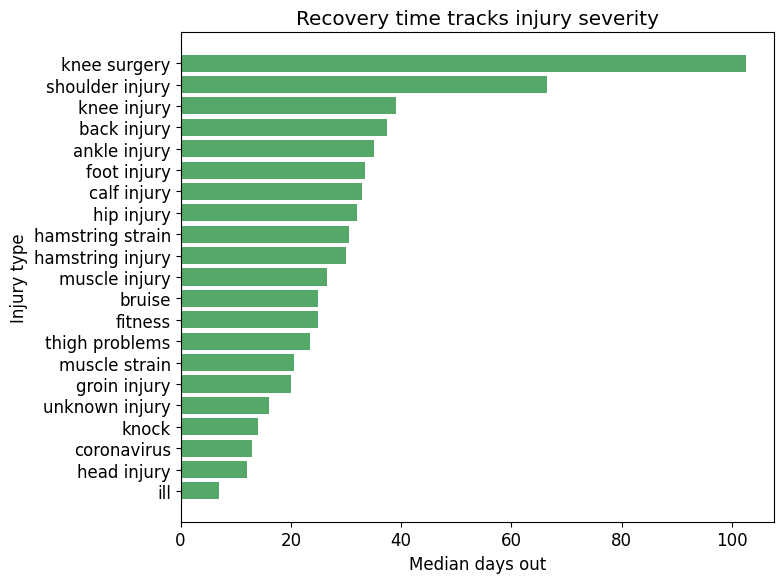

In [ ]:
# TODO: polished visualization 2

plot_data = injury_stats[injury_stats["count"] >= 5].sort_values("median")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_data.index, plot_data["median"], color="#55A868")
ax.set_xlabel("Median days out")
ax.set_ylabel("Injury type")
ax.set_title("Recovery time tracks injury severity")
plt.tight_layout()
plt.show()

**Caption 2:** Strutural injuries requiring surgery, like knee surgery (102 days), sideline player far longer than short-term absences like illness or minor knocks (under 15 days).

## Task 7: EDA Memo

Write 5 to 7 sentences for a sporting director who will never open this notebook:

- Three things you observed in the data (plain language, numbers where they help)
- One question worth building a model to answer, and why it would change a decision

**YOUR MEMO:**
Across 492 training injuries which is represented in a heavily right skewed. From the data we can see the median absence is 26 but the mean is 46.3 becuase a small number of severe, long term injuries pull the average up. Went a bit depper into player age which showed almost no relationship with recovery time, with medians staying close (25 to 28 days) across all age bands.

On the other hand we can see that injury type does matter a lot, players out for knee surgery miss a median of over 100 days, compared to under two weeks for illness or minor knocks. Our sample also likely under-represents the most severe cases. A few players are still listed as "present" (not yet returned) and are excluded from days_out entirely, meaning out typical-recovery numbers may understate how long the worrst injury really keep a player out.

One question wroth modeling: can we predict expected days out for a given injury, using injury type and player age at the time of injury?

*Write your memo here.*

## AI-Use Disclosure (required)

In 2 to 4 sentences: did you use an AI assistant, for what, and how did you verify its output? "I did not use AI this week" is a perfectly acceptable answer. What is not acceptable is code you cannot explain.

**Disclosure**
Used: walked me throguh the lab 1 to make an outline, and some help on interpretatiosn.

**Key prompts:** discussed the use of median vs mean and how to interpret when to use either or.

**What wrong / what did i change:** When running task 5 the table had a couple of grammar errors with capitals and lower case. Brainstormed how to trouble shoot that to get an accurate table.

**My judment:** I decided median was the right measure for the age/injury comparisons and picked wich findings were acutally reliable given sample size.

**Unsure: **wether the injury-type effect holds up once you control for age or position

## Submission Checklist

- [X] Every cell runs top to bottom without errors
- [X] All TODO code cells completed
- [X] All YOUR INTERPRETATION prompts answered
- [X] Memo written (Task 7)
- [X] AI-use disclosure completed
- [X] Share the notebook link with view access and submit in Canvas by Sunday, September 6, 11:59 PM ET

## Task 7: The EDA Memo (your first deliverable sentence in this course)

Every lab in this course ends with words, not code, because analysis that stays in a notebook never changed a decision. Your memo is 5 to 7 sentences: **three observations plus one modeling question**.

**Template (fill in the blanks):**

1. Observation 1: the single most striking pattern you found, with a number in it.
2. Observation 2: something about data quality or missingness, and your best hypothesis for the mechanism behind it.
3. Observation 3: one relationship between two variables, stated so a coach would understand it.
4. Modeling question: "One question worth modeling: can we predict ______ using ______?"

**Worked example** (from a different dataset, a college basketball workload log, so you can see the shape but cannot copy it):

> Across 4,200 player-game rows, minutes are strongly right-skewed: the median player logs 14 minutes while regular starters log 30 or more. Missing GPS load values cluster almost entirely on road games, which suggests the tracking hardware, not the players, drives the gaps. Players returning from a multi-game absence average about 20 percent fewer minutes in their first game back. One question worth modeling: can we predict which returning players get restricted minutes, using absence length and time of season?

**YOUR MEMO:** *Write your 5 to 7 sentences here.*

## Assumptions Check (new task)

Every analysis assumes the rows you can see represent the world you care about. The deep dive (section 4) showed our missing return dates break that quietly. Your turn to quantify it on the training split.

In [ ]:
# TODO (Assumptions Check): compare the share of severe-keyword injuries
# (cruciate|achilles|fracture|surgery) among rows you KEEP vs rows you would DROP by
# requiring days_out. Two str.contains().mean() calls. State the bias direction in one sentence.

## AI-Use Disclosure (required)

Answer the course's five standard prompts. This is the same template every week, in every lab and major assignment, so make it a habit:

1. **What did you use AI for, and with which tools?** ("I did not use AI this week" is perfectly acceptable.)
2. **What were your most important prompts?** Paste or paraphrase them.
3. **What did the AI get wrong, or what did you change from its output?**
4. **Where did your human judgment come in?** What call did you make that the AI could not?
5. **What are you still unsure about?**

Code you cannot explain is not your code.

*Write your disclosure here.*

**Co-Pilot practice log (new, from the deep dive's Co-Pilot Corner):** in 2 to 3 sentences, record the prompt you ran, the flaw pattern you checked for, and what you found. This is the week's 30-minute AI practice, logged where it belongs.

## Submission Checklist

- [ ] Every cell runs top to bottom without errors
- [ ] All TODO cells completed
- [ ] All YOUR INTERPRETATION prompts answered
- [ ] Data dictionary completed
- [ ] Two polished, captioned visualizations
- [ ] EDA memo written (3 observations + 1 modeling question, following the template)
- [ ] AI-Use Disclosure completed (all five prompts)
- [ ] Share the notebook link with view access and submit in Canvas by Sunday, September 6, 11:59 PM ET